In [1]:
import os 
import xarray as xr
import numpy as np
import pandas as pd

os.chdir('../')
from src.data.dataset import AtmosphereToRainfallDataset 

import lightning as L
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

import src.models.models as models
from src.data.datamodule import MyDataModule
from src.models.lightning_module import RegressionModel
from src.utils.config import load_config, _make_transform

import argparse
import os
import uuid
import yaml
import inspect
import numpy as np


In [2]:
ds = xr.open_dataset('./data/EastAfrica_mean_CHIRPS.nc')

In [14]:
rain_week = ds.rain.rolling(time=8,).sum().shift(time=-6)

In [18]:
rain_week_anom.quantile(0.95)

<xarray.DataArray 'rain' ()> Size: 8B
array(9.67614937)
Coordinates:
    quantile  float64 8B 0.95

(array([  37.,  468., 3642., 6729., 3853., 1169.,  362.,  111.,   45.,
          13.]),
 array([-18.71975517, -13.66804504,  -8.61633396,  -3.56462288,
          1.48708725,   6.53879738,  11.59050941,  16.64221764,
         21.69392967,  26.74564171,  31.79734802]),
 <BarContainer object of 10 artists>)

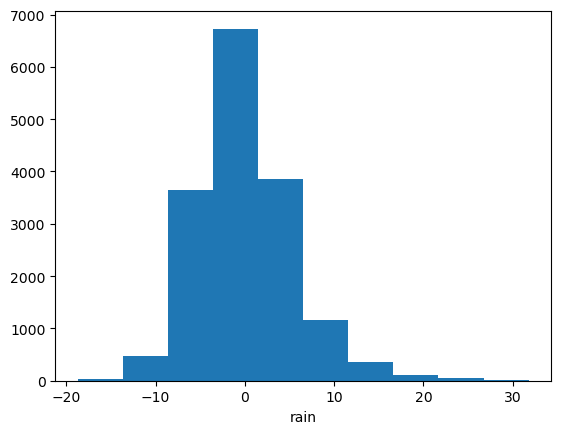

In [20]:
rain_week_anom.plot.hist()

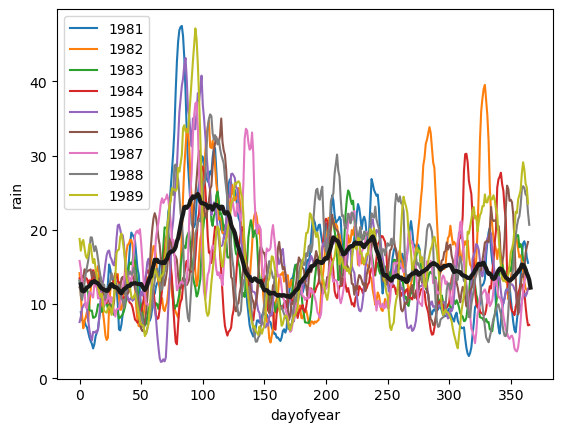

In [15]:
import matplotlib.pyplot as plt
for year in range(1981, 1990):
    plt.plot(rain_week.sel(time=str(year)).values, label=f'{year}')
rain_week.groupby('time.dayofyear').mean().plot(color='.1', lw=3)
plt.legend()
plt.show()


In [15]:
rain_week_anom = rain_week.groupby('time.dayofyear') - rain_week.groupby('time.dayofyear').mean()

rain_week_anom.to_netcdf('./data/EastAfrica_mean_CHIRPS_7day_anom.nc')

In [13]:
ds.rain.rolling(time=7).sum().shift(time=-6).fillna(0).to_netcdf('./data/EastAfrica_mean_CHIRPS_7day.nc')

(array([6.000e+00, 1.000e+00, 9.000e+00, 5.400e+01, 7.400e+02, 3.167e+03,
        6.287e+03, 4.710e+03, 1.288e+03, 1.740e+02]),
 array([0.        , 0.38890731, 0.77781463, 1.16672194, 1.55562925,
        1.94453657, 2.33344388, 2.72235107, 3.11125851, 3.50016594,
        3.88907313]),
 <BarContainer object of 10 artists>)

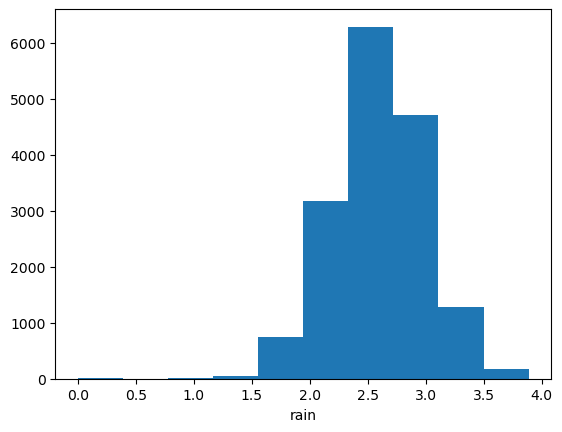

In [15]:
np.log1p(ds.rain.rolling(time=7).sum().shift(time=-6).fillna(0)).plot.hist()

In [2]:
config = load_config('./configs/default_config.yml')

In [3]:
project_dir = os.path.join(config['logging']['base_dir'], config['logging']['project'])
run_id = uuid.uuid4().hex[:8]
out_dir = os.path.join(project_dir, run_id)
# Check that the run_id does not already exist to avoid overwriting previous runs. If it does, generate a new one.
while os.path.exists(out_dir):
    run_id = uuid.uuid4().hex[:8]
    out_dir = os.path.join(project_dir, run_id)
os.makedirs(out_dir)

# Sets up the W&B logger with the specified project name, entity, run name, and configuration. The logs will be saved in the output directory for this run.
wandb_logger = WandbLogger(
    project=config['logging']['project'],
    entity=config['logging'].get('entity'),
    name=config['logging'].get('run_name'),
    id=run_id,
    version=run_id,
    config=config,
    save_dir=out_dir
)
print(f"W&B run id: {run_id}")
print(f"W&B run url: {wandb_logger.experiment.url}")

# Save config file for reproducibility
with open(os.path.join(out_dir, "config.yaml"), "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)


W&B run id: b45b9771


wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/robin/.netrc.
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run url: https://wandb.ai/rguilcas-university-of-bergen/african-rainfall-tests/runs/b45b9771


In [4]:
transform_X = _make_transform(config["data"].get("transform_X"))
transform_y = _make_transform(config["data"].get("transform_y"))

# Loads the datamodule using MyDataModule class, which handles loading the dataset and applying the specified transformations.
datamodule = MyDataModule(
    data_in_name=config['data']['data_in_name'],
    data_target_name=config['data']['data_target_name'],
    data_path=config['data']['data_path'],
    batch_size=config['data']['batch_size'],
    transform_X=transform_X,
    transform_y=transform_y,
)

In [5]:
model_class = getattr(models, config["model"]["model_name"])
model_config = {
    **config["model"],
    "image_size": datamodule.image_size,
    "n_channels_input_cnn": config["model"]["n_channels_input_cnn"],
    "input_size": datamodule.image_size * config["model"]["n_channels_input_cnn"],
    "target_size": 1,
}
constructor_params = inspect.signature(model_class.__init__).parameters
allowed_kwargs = {
    name: value
    for name, value in model_config.items()
    if name in constructor_params and name != "self"
}
neural_network = model_class(**allowed_kwargs)

In [6]:
neural_network

TwoLayerCNN(
  (relu): ReLU()
  (conv1): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): LazyLinear(in_features=0, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

In [7]:
datamodule.setup('fit')

Fitting transforms on the training data...


In [8]:
sample = datamodule.dataset_val[0]
X_test = sample['x'].unsqueeze(0)  # Add batch dimension: [C,H,W] -> [1,C,H,W]
neural_network(X_test)

tensor([[-0.0777]], grad_fn=<AddmmBackward0>)

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [2]:
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=4, threads_per_worker=1, memory_limit='4GB')
client = Client(cluster)
client

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40103 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:40103/status,
Dashboard: http://127.0.0.1:40103/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41039,Workers: 0
Dashboard: http://127.0.0.1:40103/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41441,Total threads: 1
Dashboard: http://127.0.0.1:38517/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:34941,


2026-06-22 17:18:43,285 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:41441' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 3, 73, 0, 0), ('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 1, 97, 0, 0), ('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 3, 125, 0, 0), ('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 1, 99, 0, 0), ('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 3, 48, 0, 0), ('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 3, 87, 0, 0), ('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 3, 47, 0, 0), ('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 3, 53, 0, 0), ('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 3, 25, 0, 0), ('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 3, 110, 0, 0), ('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 3, 124, 0, 0), ('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 3, 59, 0, 0), ('getitem-5eb0440f0fdd026dd2f1a4f31fb450aa', 3, 31, 0, 0), ('open_dataset-msl-stack-8f35ed816a72ac8

In [2]:
dataset = AtmosphereToRainfallDataset()

tensor([[[ 3.2324e+00,  4.7669e+00,  4.1602e+00,  ...,  8.2946e-01,
          -2.5720e+00, -1.4293e+00],
         [ 2.3573e+00,  8.9790e-01,  2.6418e+00,  ..., -6.8591e+00,
          -6.1192e+00, -5.4935e+00],
         [-3.2382e+00, -3.6745e+00, -3.8814e+00,  ..., -5.8211e+00,
          -4.8319e+00, -3.8584e+00],
         ...,
         [-6.8111e-01,  1.5025e+00,  2.5467e+00,  ..., -4.2387e+00,
          -1.1307e+00, -2.6342e+00],
         [-1.8125e+00, -2.6018e-01,  1.3280e+00,  ..., -1.2949e+00,
          -3.0078e+00,  1.8834e-02],
         [-2.5694e+00, -1.4502e+00, -1.8975e+00,  ...,  5.0234e+00,
           2.0392e+00, -1.3985e+00]],

        [[ 4.3237e+00,  5.7292e+00,  3.2932e+00,  ...,  4.8644e-01,
          -1.4790e+00, -1.1166e+00],
         [ 3.4544e+00,  3.8762e+00,  1.4014e+00,  ..., -8.5961e-01,
          -9.1026e-01,  1.6631e-01],
         [ 3.1073e+00,  3.2855e+00,  1.3869e+00,  ...,  2.4437e-01,
           5.2240e-01,  3.8623e-01],
         ...,
         [-1.9024e+00, -5

In [8]:
data_in_name='lowres_era5_features.nc'
data_target_name='EastAfrica_mean_CHIRPS.nc'
transform_X=None
transform_y=None
data_path = '/Data/gfi/users/rogui7909/data/AfricaPrecip'

time_slice = (None,None)
"""
Initializes the dataset by loading the input and target data from NetCDF files, applying any specified transformations, and preparing the data for indexing.
The dataset also aligns inputs and target data and determines their common time steps. The data are filtered accordingly.
"""
# ds_in = load_predictors(data_path, data_in_path)
# ds_target = xr.open_dataarray(os.path.join(data_path, data_target_name))
# # computes common times between predictors and targets and filter the data accordingly.
# common_times = np.intersect1d(ds_in.time.values, ds_target.time.values)
# ds_total = xr.Dataset({'predictors': ds_in, 'targets': ds_target}).sel(time=common_times)
# # store xarray dataset and transformations as attributes.
# # self.ds = ds_total.sel(time=common_times).sel(time=slice(time_slice[0], time_slice[1]))
# # self.transform_X = transform_X
# # self.transform_y = transform_y
# # self.times = self.ds.time.values

'\nInitializes the dataset by loading the input and target data from NetCDF files, applying any specified transformations, and preparing the data for indexing.\nThe dataset also aligns inputs and target data and determines their common time steps. The data are filtered accordingly.\n'

In [25]:
ds_in = xr.open_dataarray(os.path.join(data_path, data_in_name), chunks = dict(time=120))
ds_target = xr.open_dataarray(os.path.join(data_path, data_target_name))
ds_target = ds_target.assign_coords(time=pd.to_datetime(ds_target.time.dt.date))
# computes common times between predictors and targets and filter the data accordingly.
common_times = np.intersect1d(ds_in.time.values, ds_target.time.values)
ds_total = xr.Dataset({'predictors': ds_in, 'targets': ds_target}).sel(time=common_times)

In [26]:
ds_total

<xarray.Dataset> Size: 329MB
Dimensions:     (longitude: 25, latitude: 25, time: 16436, var_name: 4)
Coordinates:
  * longitude   (longitude) float32 100B -60.0 -57.5 -55.0 ... -5.0 -2.5 0.0
  * latitude    (latitude) float32 100B 30.0 27.5 25.0 ... -25.0 -27.5 -30.0
  * time        (time) datetime64[ns] 131kB 1981-01-01 1981-01-02 ... 2025-12-31
  * var_name    (var_name) <U3 48B 'u' 'v' 't2m' 'msl'
Data variables:
    predictors  (var_name, time, latitude, longitude) float64 329MB dask.array<chunksize=(4, 119, 25, 25), meta=np.ndarray>
    targets     (time) float32 66kB 2.107 1.445 0.6152 ... 3.611 3.612 3.174

In [19]:
ds_target.time

<xarray.DataArray 'time' (time: 16436)> Size: 131kB
array([datetime.date(1981, 1, 1), datetime.date(1981, 1, 2),
       datetime.date(1981, 1, 3), ..., datetime.date(2025, 12, 29),
       datetime.date(2025, 12, 30), datetime.date(2025, 12, 31)],
      shape=(16436,), dtype=object)
Coordinates:
  * time     (time) object 131kB 1981-01-01 1981-01-02 ... 2025-12-30 2025-12-31

In [5]:
all_predictors = []
for file in files:
    da = xr.open_dataset(file, chunks = dict(time=120))
    all_predictors.append(da)
ds_in = xr.merge(all_predictors)#.to_array('var_name')

In [1]:
(((ds_in.isel(time=0).to_array('var_name')-ds_in.isel(time=0).to_array('var_name').mean(['longitude','latitude'])))/ds_in.isel(time=0).to_array('var_name').std(['longitude','latitude'])).plot(col='var_name')

NameError: name 'ds_in' is not defined

In [6]:
ds_out = ds_in.to_array('var_name').isel(latitude=np.arange(0,122, 5), longitude=np.arange(0,122, 5)).load()

There are 34 HDF5 objects open!

Report: open objects on 72057594037927937


Type = File(72057594037927936) name='/'

There are 1 HDF5 objects open!

Report: open objects on 72057594037927936


In [7]:
ds_out.to_netcdf('/Data/gfi/users/rogui7909/data/AfricaPrecip/lowres_era5_features.nc')